<a href="https://colab.research.google.com/github/lawilbee/mte544/blob/main/Lab1/Part3/MTE544_A1_P3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install matplotlib numpy

In [2]:
%%writefile omniSim.py
import numpy as np
import os
import matplotlib.pyplot as plt

# Simulate the omniwheel robot motion over 30s with 0.1s time stamps and
# initial position at the origin
def simulate(u_func, G_inv, t_total=30.0, dt=0.1, pos_init=(0.0, 0.0, 0.0)):
    # determine # of steps and set time array
    n_steps = int(round(t_total / dt)) + 1
    t = np.linspace(0.0, t_total, n_steps)

    # initialize data arrays
    x = np.zeros(n_steps)
    y = np.zeros(n_steps)
    theta = np.zeros(n_steps)
    xdot_hist = np.zeros(n_steps)
    ydot_hist = np.zeros(n_steps)
    w_hist = np.zeros(n_steps)

    # Initialize the robot position
    x[0], y[0], theta[0] = pos_init
    # Iterate functions over the range at given timestamps
    for k in range(n_steps - 1):
        u_k = u_func(t[k])
        G_inv_k = G_inv(theta[k])
        qdot = G_inv_k @ u_k
        xdot_hist[k] = qdot[0, 0]
        ydot_hist[k] = qdot[1, 0]
        w_hist[k] = qdot[2, 0]
        # store position
        x[k + 1] = x[k] + xdot_hist[k] * dt
        y[k + 1] = y[k] + ydot_hist[k] * dt
        theta[k + 1] = theta[k] +  w_hist[k] * dt
    # record final-step velocities (fixes plot suddenly dropping to 0)
    qdot_last = G_inv(theta[-1]) @ u_func(t[-1])
    xdot_hist[-1], ydot_hist[-1], w_hist[-1] = qdot_last[0,0], qdot_last[1,0], qdot_last[2,0]

    # Filter data to remove floating point rounding noise
    x = np.where(np.abs(x) < 1e-9, 0.0, x)
    y = np.where(np.abs(y) < 1e-9, 0.0, y)
    theta = np.where(np.abs(theta) < 1e-9, 0.0, theta)
    xdot_hist = np.where(np.abs(xdot_hist) < 1e-9, 0.0, xdot_hist)
    ydot_hist = np.where(np.abs(ydot_hist) < 1e-9, 0.0, ydot_hist)
    w_hist = np.where(np.abs(w_hist) < 1e-9, 0.0, w_hist)

    return t, x, y, theta, xdot_hist, ydot_hist, w_hist

# Plot the 2D trajectory and each variable against time
# for the given test case
def plot_case(t, x, y, theta, xdot_hist, ydot_hist, w_hist, title, fname_prefix,out_dir='.'):

    # 2D trajectory plot (x vs y)
    fig1, ax1 = plt.subplots(figsize=(6, 6))
    ax1.plot(x, y, linewidth=2)
    ax1.plot(x[0], y[0], 'go', label='Start')
    ax1.plot(x[-1], y[-1], 'ro', label='End')
    ax1.set_xlabel('x [m]')
    ax1.set_ylabel('y [m]')
    ax1.set_title(f'2D Trajectory: {title}')
    ax1.axis('equal')
    ax1.grid(True)
    ax1.legend()
    fig1.tight_layout()
    fig1.savefig(os.path.join(out_dir, f'{fname_prefix}_trajectory.png'), dpi=150)
    #plt.close(fig1)
    plt.show(fig1)

    # Time-series plots: x(t), y(t), theta(t)
    fig2, ax2 = plt.subplots(3, 1, figsize=(8, 9), sharex=True)

    ax2[0].plot(t, x, linewidth=2)
    ax2[0].set_ylabel('x [m]')
    ax2[0].set_title(f'Pos vs time: {title}')
    ax2[0].grid(True)

    ax2[1].plot(t, y, linewidth=2, color='tab:orange')
    ax2[1].set_ylabel('y [m]')
    ax2[1].grid(True)

    ax2[2].plot(t, theta, linewidth=2, color='tab:green')
    ax2[2].set_ylabel(r'$\theta$ [rad]')
    ax2[2].set_xlabel('time [s]')
    ax2[2].grid(True)

    fig2.tight_layout()
    fig2.savefig(os.path.join(out_dir, f'{fname_prefix}_pos_vs_time.png'), dpi=150)
    #plt.close(fig2)
    plt.show(fig2)

    # Time-series plots: xdot(t), ydot(t), w(t)
    fig3, ax3 = plt.subplots(3, 1, figsize=(8, 6), sharex=True)
    ax3[0].plot(t, xdot_hist, linewidth=2)
    ax3[0].set_ylabel('$\dot{x}$ [m/s]')
    ax3[0].set_title(f'Velocity vs time: {title}')
    ax3[0].grid(True)

    ax3[1].plot(t, ydot_hist, linewidth=2, color='tab:orange')
    ax3[1].set_ylabel('$\dot{y}$ [m/s]')
    ax3[1].grid(True)

    ax3[2].plot(t, w_hist, linewidth=2, color='tab:red')
    ax3[2].set_ylabel(r'$\omega$ [rad/s]')
    ax3[2].set_xlabel('time [s]')
    ax3[2].grid(True)

    fig3.tight_layout()
    fig3.savefig(os.path.join(out_dir, f'{fname_prefix}_velo_vs_time.png'), dpi=150)
    #plt.close(fig3)
    plt.show(fig3)

# Combine u functions into a column vector
def make_u_func(u1_func, u2_func, u3_func):
    return lambda t: np.array([[u1_func(t)], [u2_func(t)], [u3_func(t)]])

# Construct G() and return the inverse
def Ginv_func(r_val, l_val):
    beta1, beta2, beta3 = np.pi/2, -5*np.pi/6, -np.pi/6

    def Ginv(theta):
        G = (1.0 / r_val) * np.array([
            [np.cos(theta + beta1), np.sin(theta + beta1), l_val],
            [np.cos(theta + beta2), np.sin(theta + beta2), l_val],
            [np.cos(theta + beta3), np.sin(theta + beta3), l_val]
        ])
        return np.linalg.inv(G)

    return Ginv

# Run the simulation for Part 3
def runSim():
    T_TOTAL = 30.0 # total time (s)
    DT = 0.1 # time step (s)
    # Save plots to path
    #SCRIPT_DIR = os.path.dirname(os.path.abspath(__file__))
    #PLOTS_DIR = os.path.join(SCRIPT_DIR, 'plots')
    PLOTS_DIR = './plots'
    os.makedirs(PLOTS_DIR, exist_ok=True)
    # System parameters
    r = 0.1 # Radius (m)
    l = 0.25 # Wheel distance (m)
    R = 1 # ii_2) circle diameter (m)
    # Construct the inverse matix G()^-1
    G_inv = Ginv_func(r,l)
    # Define cases required
    cases = [
            {
                'name': 'i: u1=-2, u2=1, u3=1',
                'prefix': 'i',
                'u1_func': lambda t: -2.0,
                'u2_func': lambda t: 1.0,
                'u3_func': lambda t: 1.0
            },
            {
                'name': 'ii_1: Straight Line w 60 Degree Slope',
                'prefix': 'ii_1',
                'u1_func': lambda t: np.sqrt(3)/2,
                'u2_func': lambda t: -np.sqrt(3)/2,
                'u3_func': lambda t: 0
            },
            {
                'name': 'ii_2: Circle with 2m Diameter',
                'prefix': 'ii_2',
                'u1_func': lambda t: R/r * np.cos(t),
                'u2_func': lambda t: np.sqrt(3)/2 * R/r *np.sin(t) - R/(2*r) * np.cos(t),
                'u3_func': lambda t: -np.sqrt(3)/2 * R/r *np.sin(t) - R/(2*r) * np.cos(t)
            },
    ]
    # Run the 3 test cases
    for case in cases:
        case['u_func'] = make_u_func(case['u1_func'], case['u2_func'], case['u3_func'])
        # Run model simulation
        t, x, y, theta, xdot_hist, ydot_hist, w_hist = simulate(
            case['u_func'], G_inv, t_total=T_TOTAL, dt=DT
        )
        # Plot sim results
        plot_case(t, x, y, theta, xdot_hist, ydot_hist, w_hist, case['name'], case['prefix'], PLOTS_DIR)

    print(f"\n Simulation complete. All plots saved in folder")

Writing omniSim.py


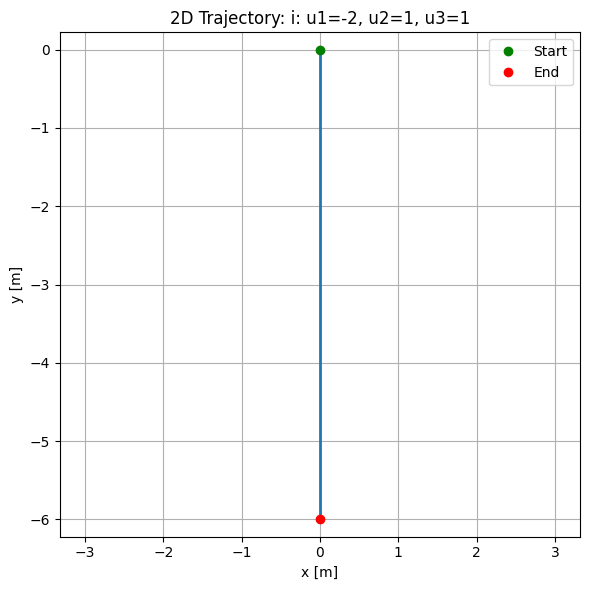

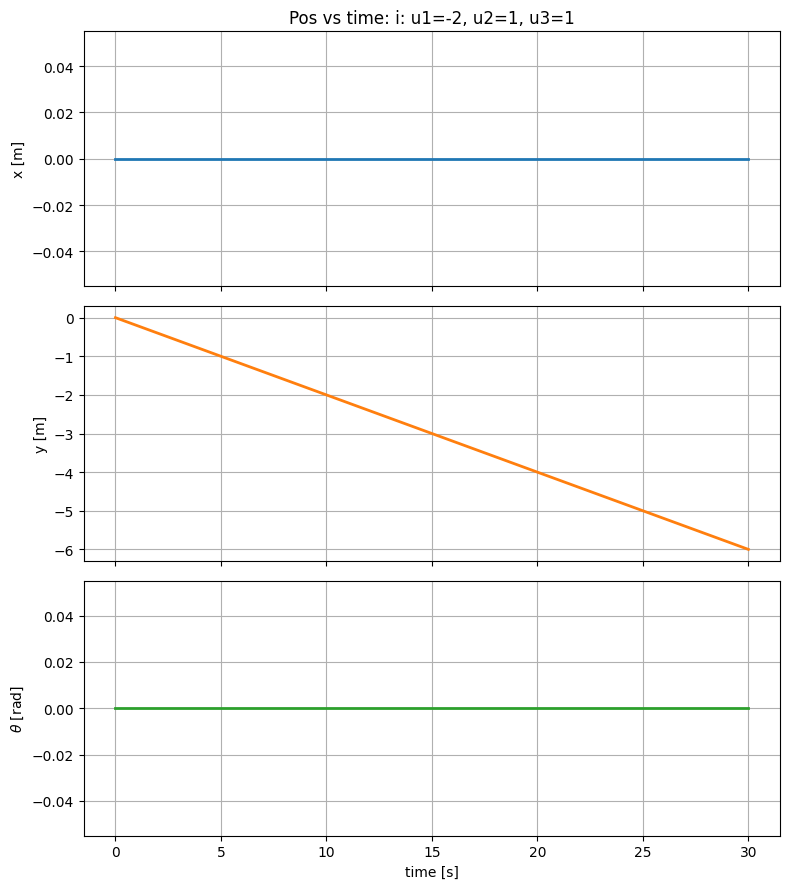

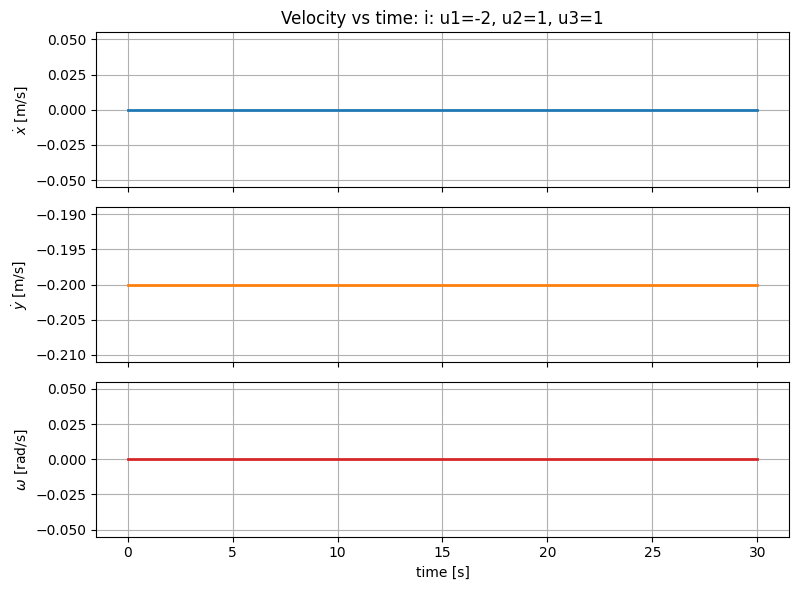

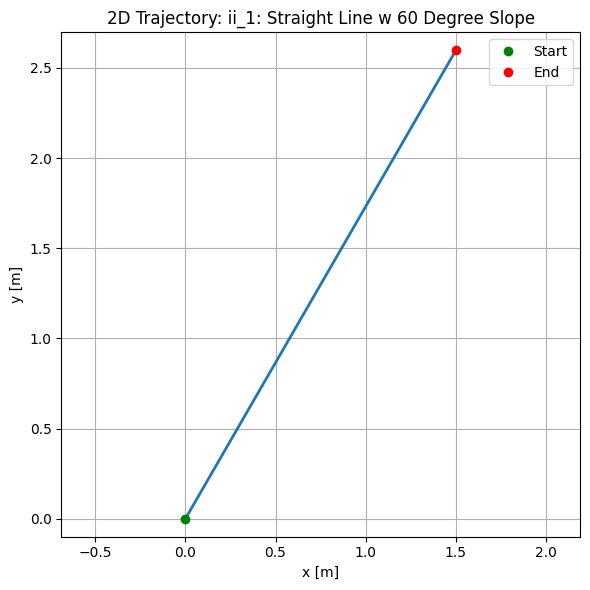

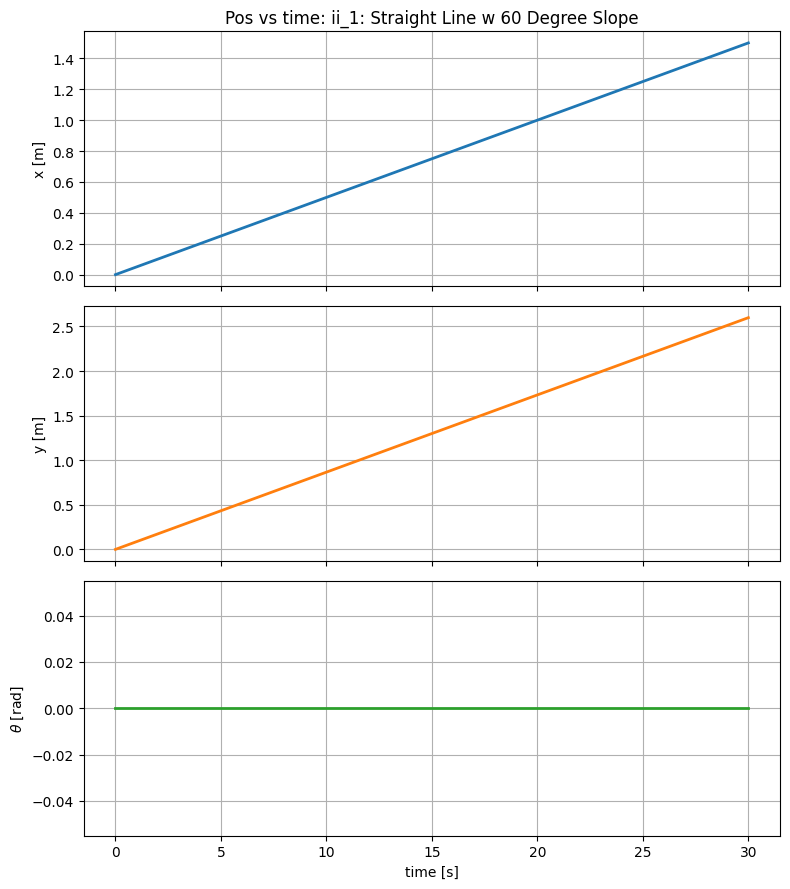

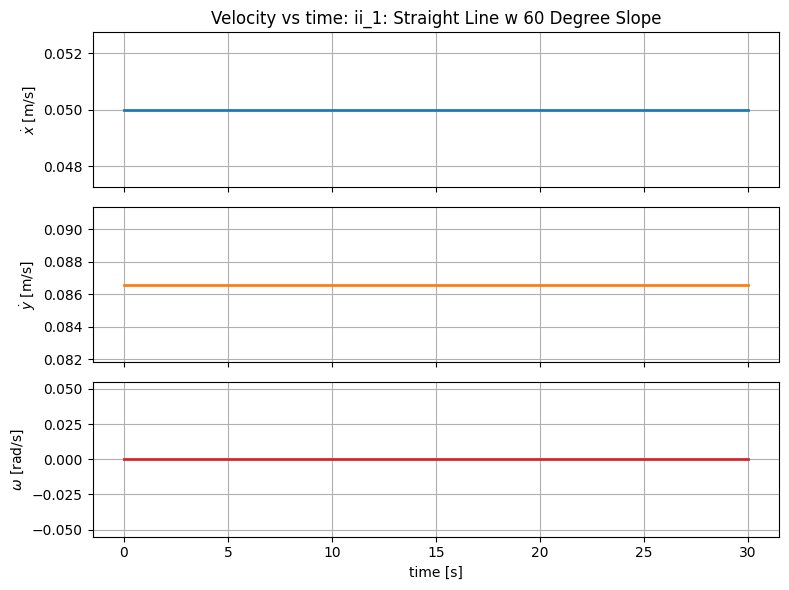

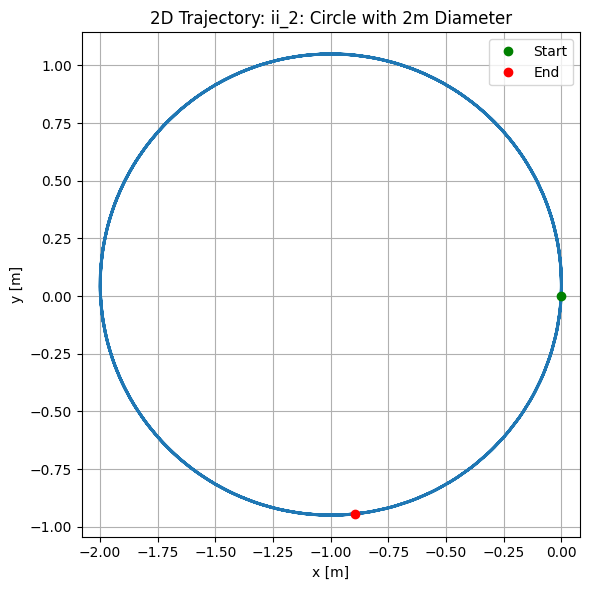

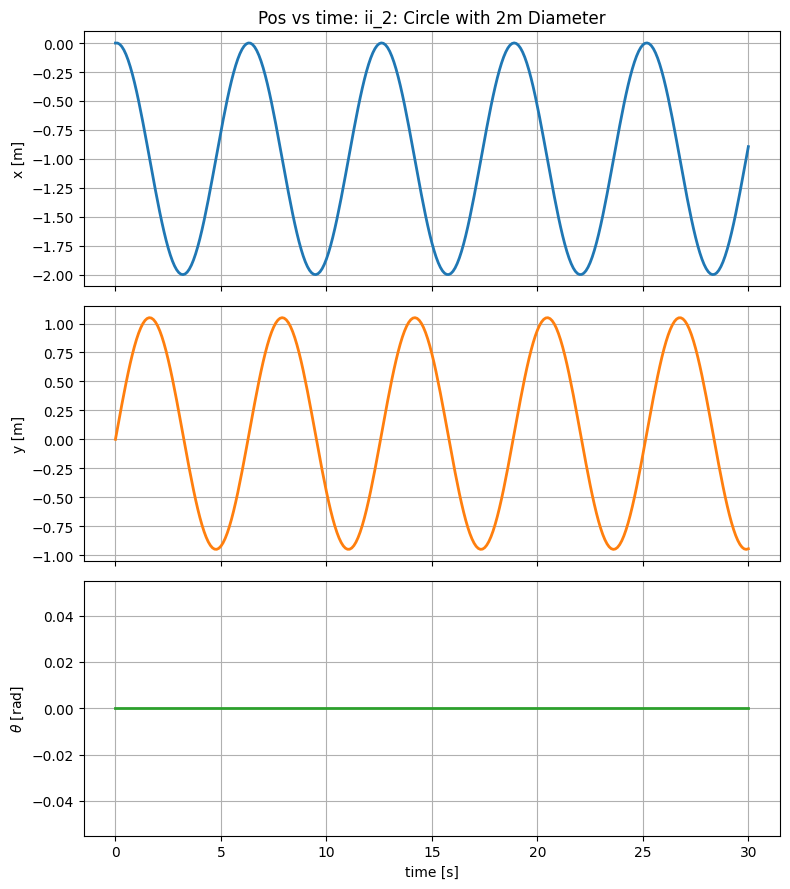

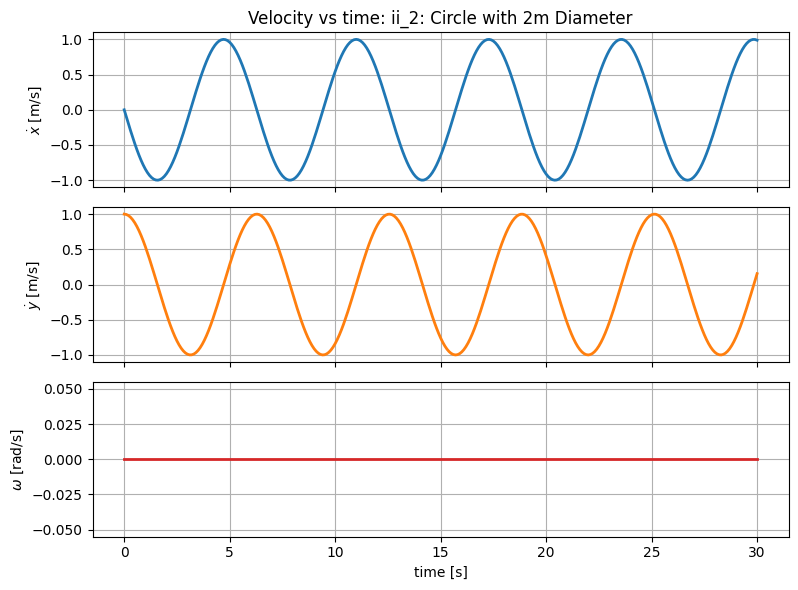


 Simulation complete. All plots saved in folder


In [4]:
import importlib
import omniSim
importlib.reload(omniSim)
from omniSim import runSim

def main():
    runSim()

if __name__ == "__main__":
    main()